In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import sys

from scripts.contrast_functions import get_contrasts_from_img, create_histogram_plots
from scripts.annotation_class import watershed_annotator

import time
import json

## Setting some constants

| Parameter             | Description                                                                                                                                    |
| --------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| `FLAKE_DIRECTORY`     | The directory path of the saved images; the images need to be in `.jpg`, `.png` , or `.tif` format.                                                       |
| `MASK_SAVE_DIRECTORY` | The directory path where the semantic masks are saved.                                                       |
| `ANNOTATE`            | If the images are already annotated or not, if you want to annotate images and save the results to `MASK_SAVE_DIRECTORY` toggle this to `TRUE` |
| `USE_FLATFIELD`       | Whether to use a flatfield image or not (It is highly recommended to use a flatfield image)                                                                                                        |
| `FLATFIELD_PATH`      | The Path to the flatfield image                                                                                                                |
| `USED_CHANNELS `      | The channels used to fit the GM-Model, if, for example, your Blue Channel is Weak you may want to only use `RG`                                |
| `AXIS_NAMES`          | The names used when plotting for the axes                                                                                                      |

As the Supplied Datasets already have their flatfield removed, the default for `USE_FLATFIELD` is set to `False`.  
If you want to use a flatfield image, you need to set `USE_FLATFIELD` to `True` and set the path to the flatfield image in `FLATFIELD_PATH`.


In [2]:
IMAGE_DIRECTORY = r"../Datasets/GMMDetectorDatasets/contrast_tests/blue_balance/test_images"
MASK_SAVE_DIRECTORY = r"../Datasets/GMMDetectorDatasets/contrast_tests/blue_balance/masks"

USE_FLATFIELD = False
FLATFIELD_PATH = r"../Datasets/GMMDetectorDatasets/contrast_tests/casper_chip_3_flatfield_MMStack_Pos0.ome.tif"

CREATE_NEW_MASK = False
SAVE_RESULTS = True
RESULTS_DIRECTORY = r"../Datasets/GMMDetectorDatasets/contrast_tests/blue_balance/results"

USED_CHANNELS = "BGR"
AXIS_NAMES = ["Blue Contrast", "Green Contrast", "Red Contrast"]

## Checking if the given Parameters are valid


In [3]:
assert os.path.exists(IMAGE_DIRECTORY), "Flake directory does not exist"
if USE_FLATFIELD:
    assert os.path.exists(FLATFIELD_PATH), "Flatfield image does not exist"

assert len(USED_CHANNELS) in [2, 3], "We need 2 or 3 channels for the GMM"

os.makedirs(MASK_SAVE_DIRECTORY, exist_ok=True)

## Annotating the Images in the Folder

The annotator uses the watershed algorithm to discern the foreground from the background.  
It is only necessary to define these two classes as the thickness is inferred later by the clustering.

A red outline is shown between the background and foreground indicating the mask boundry.

The Masks are saved as `.png` files in the `MASK_SAVE_DIRECTORY` Folder with the same name as the image.

### Controls

|            Keys             | Description                                                  |
| :-------------------------: | ------------------------------------------------------------ |
| <kbd>A</kbd> / <kbd>D</kbd> | Previous / Next Image                                        |
|        <kbd>S</kbd>         | Save the current annotion, very important after every image! |
|        <kbd>C</kbd>         | Delete the current annotations                               |
|    <kbd>Left MBT </kbd>     | Set a marker for foreground                                  |
|    <kbd>Right MBT </kbd>    | Set a marker for background                                  |
|       <kbd>ESC</kbd>        | Exit the program                                             |


In [4]:
if CREATE_NEW_MASK:
    annotator = watershed_annotator(
        image_directory=IMAGE_DIRECTORY,
        mask_directory=MASK_SAVE_DIRECTORY,
    )
    annotator.run()

## Calculate contrast graphs
Now it calculates the background color from the flatfield, and uses the mask(s) to calculate flake colors. Then the contrast between the background and flake colors are plotted on graphs for each image.

Using mask: 0.5_blue_balance.tif


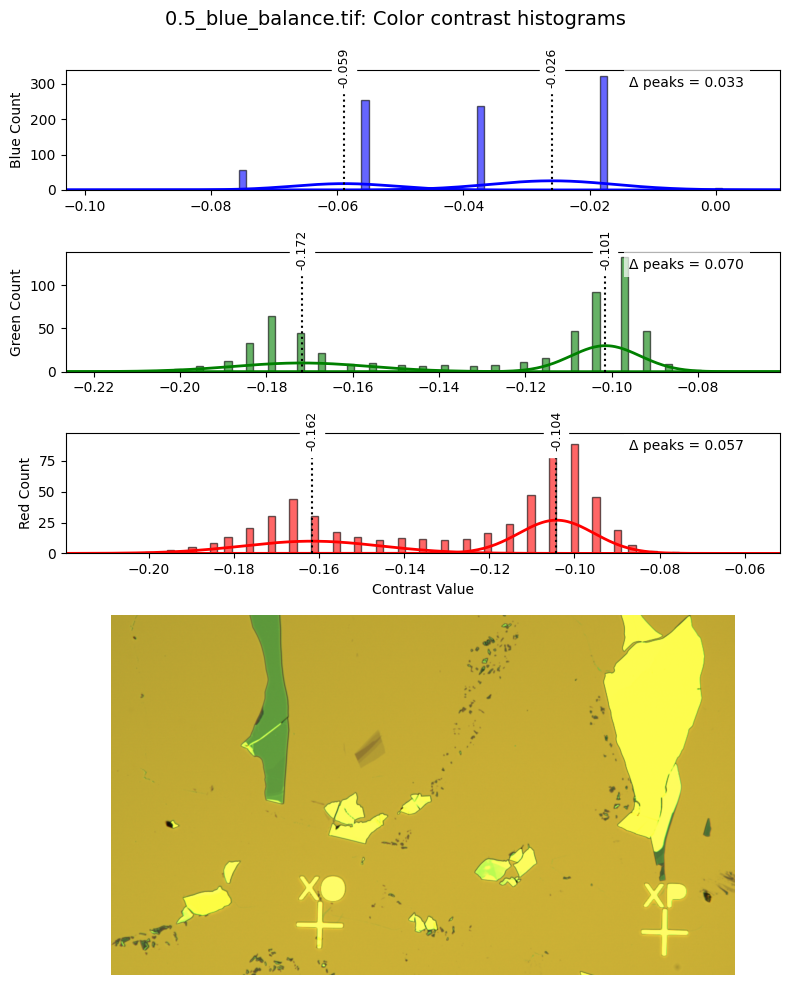

Saved histogram plot to ../Datasets/GMMDetectorDatasets/contrast_tests/blue_balance/results


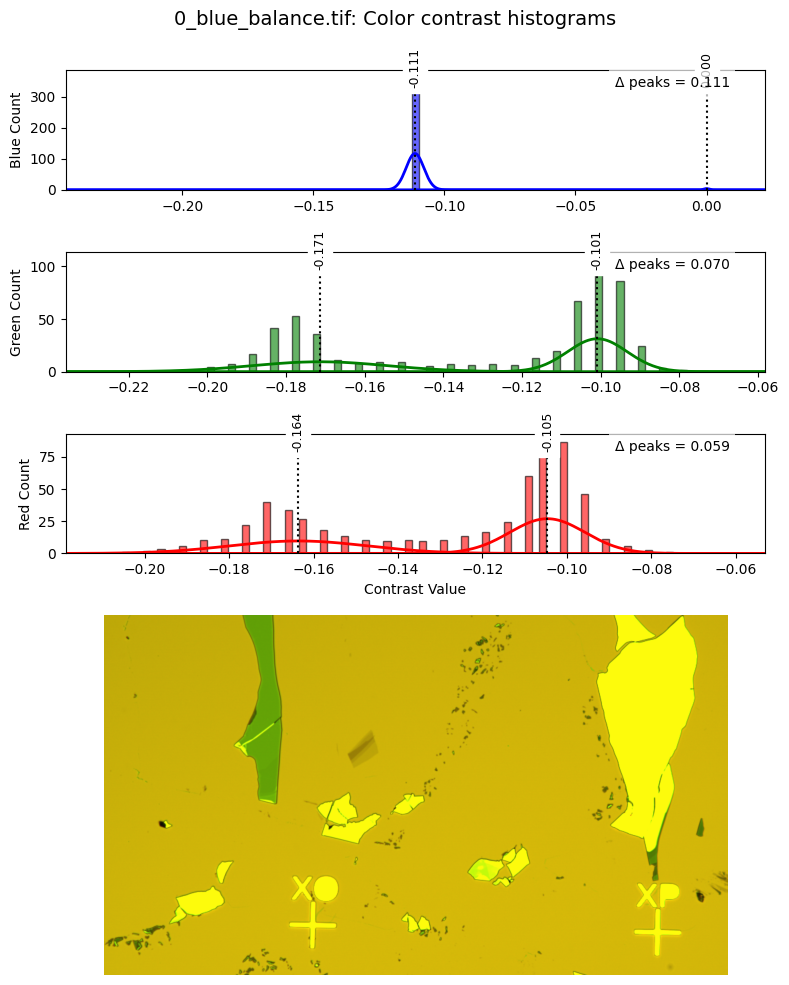

Saved histogram plot to ../Datasets/GMMDetectorDatasets/contrast_tests/blue_balance/results


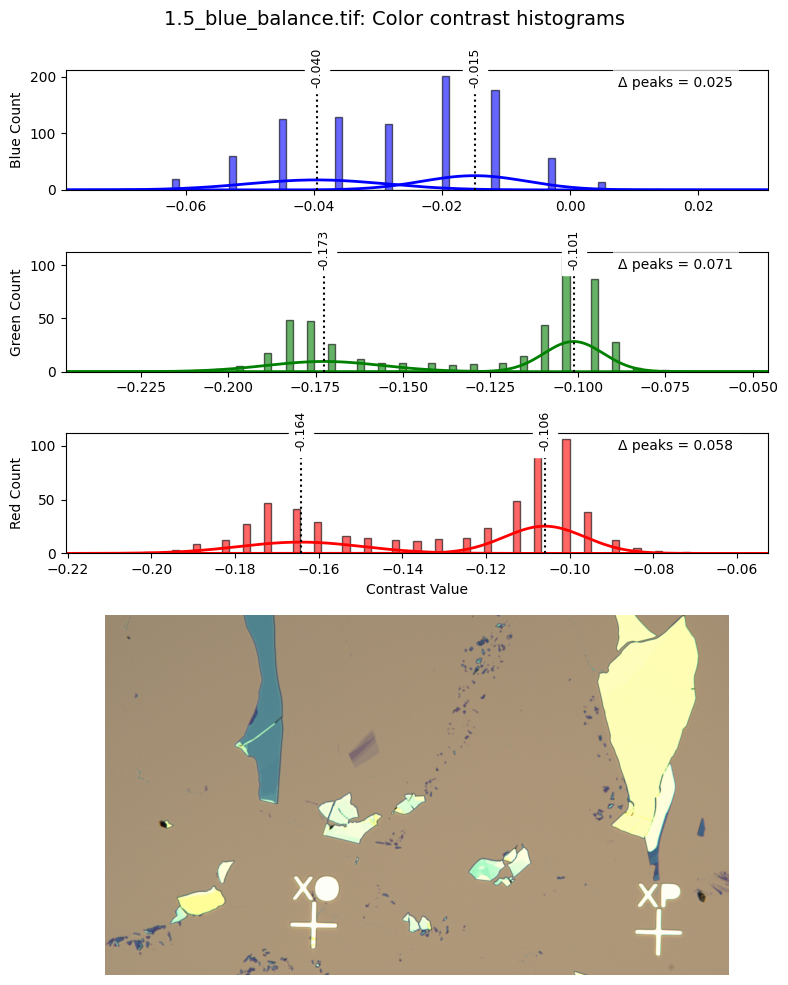

Saved histogram plot to ../Datasets/GMMDetectorDatasets/contrast_tests/blue_balance/results


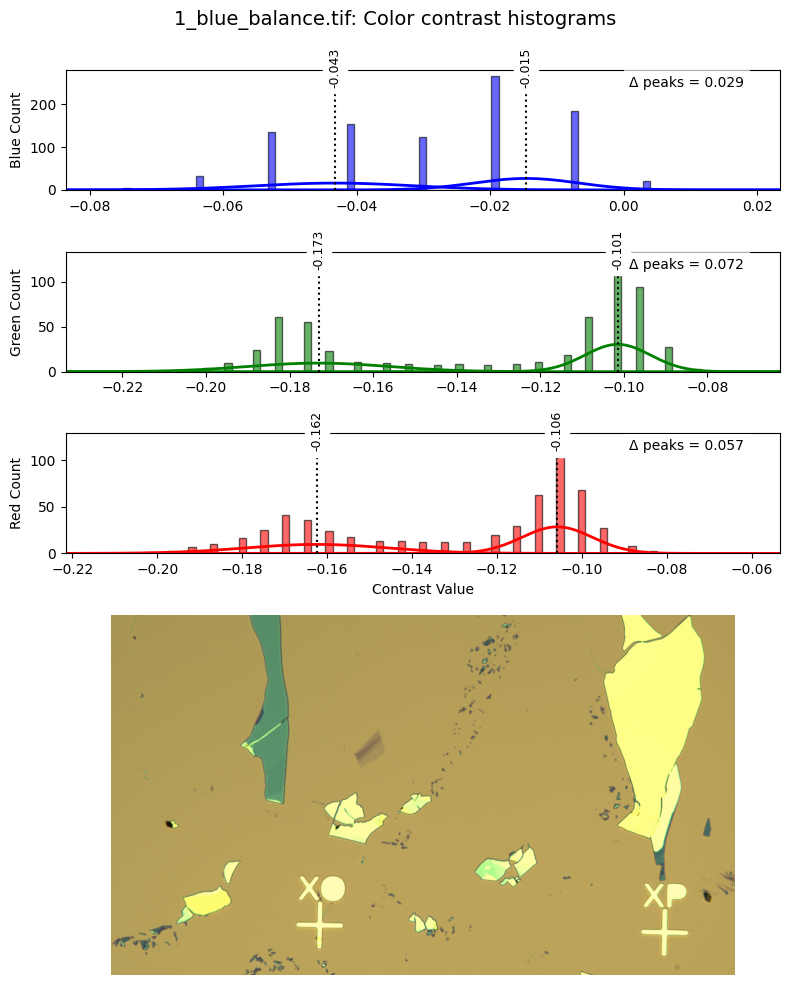

Saved histogram plot to ../Datasets/GMMDetectorDatasets/contrast_tests/blue_balance/results


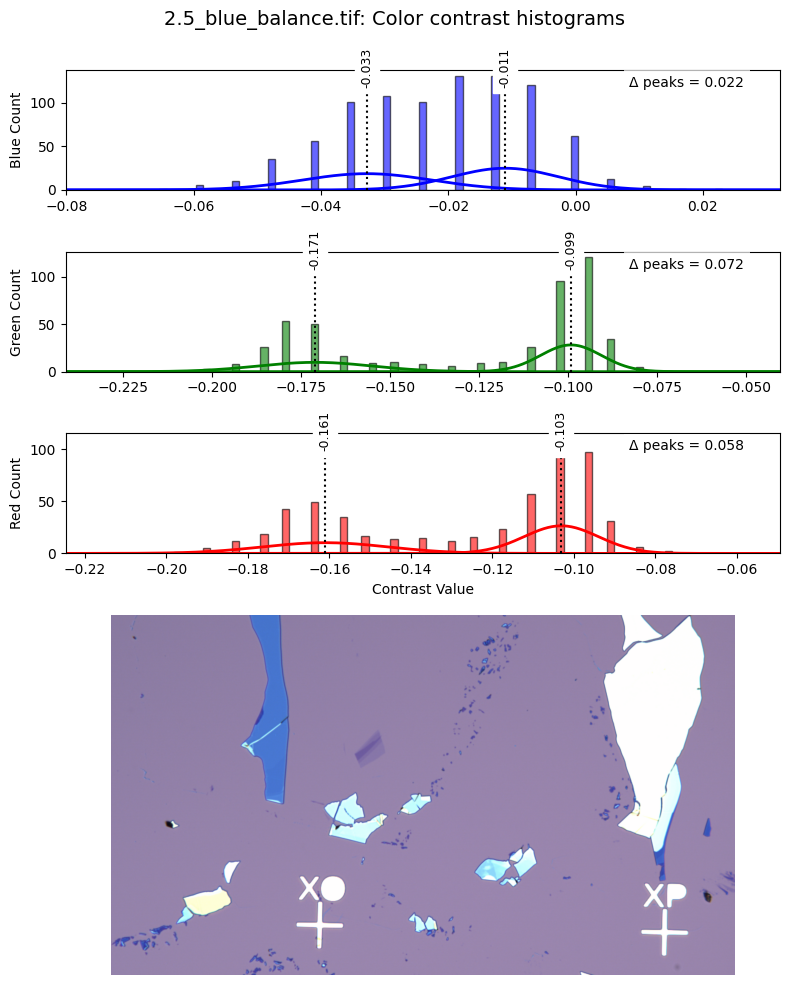

Saved histogram plot to ../Datasets/GMMDetectorDatasets/contrast_tests/blue_balance/results


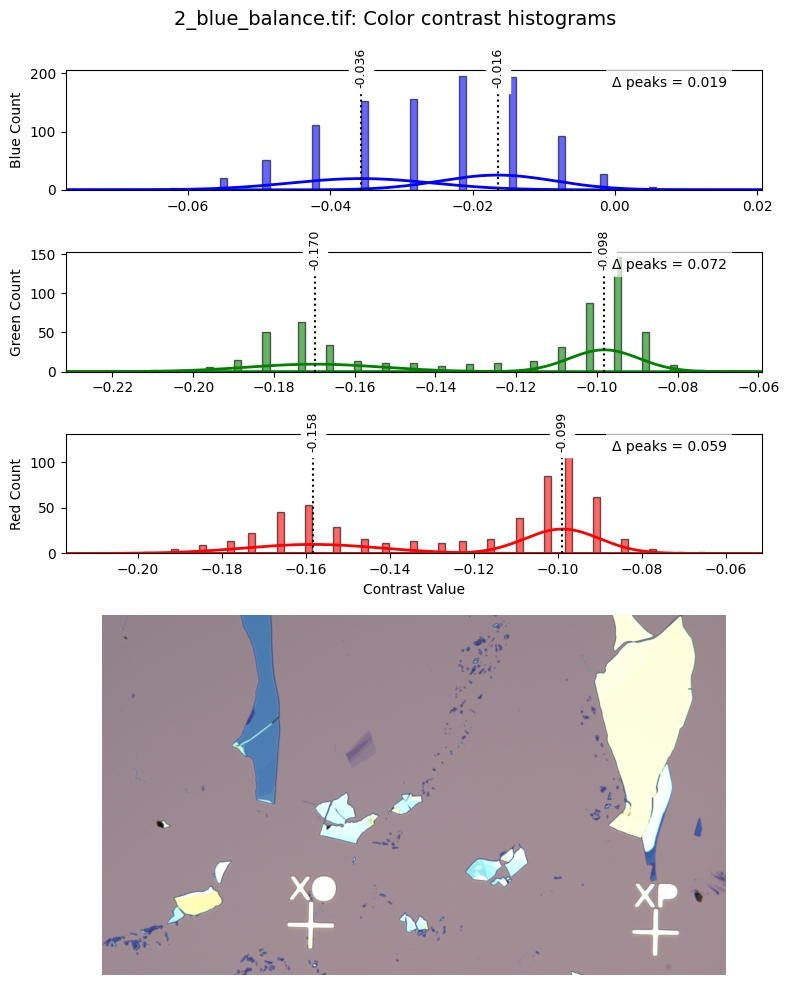

Saved histogram plot to ../Datasets/GMMDetectorDatasets/contrast_tests/blue_balance/results


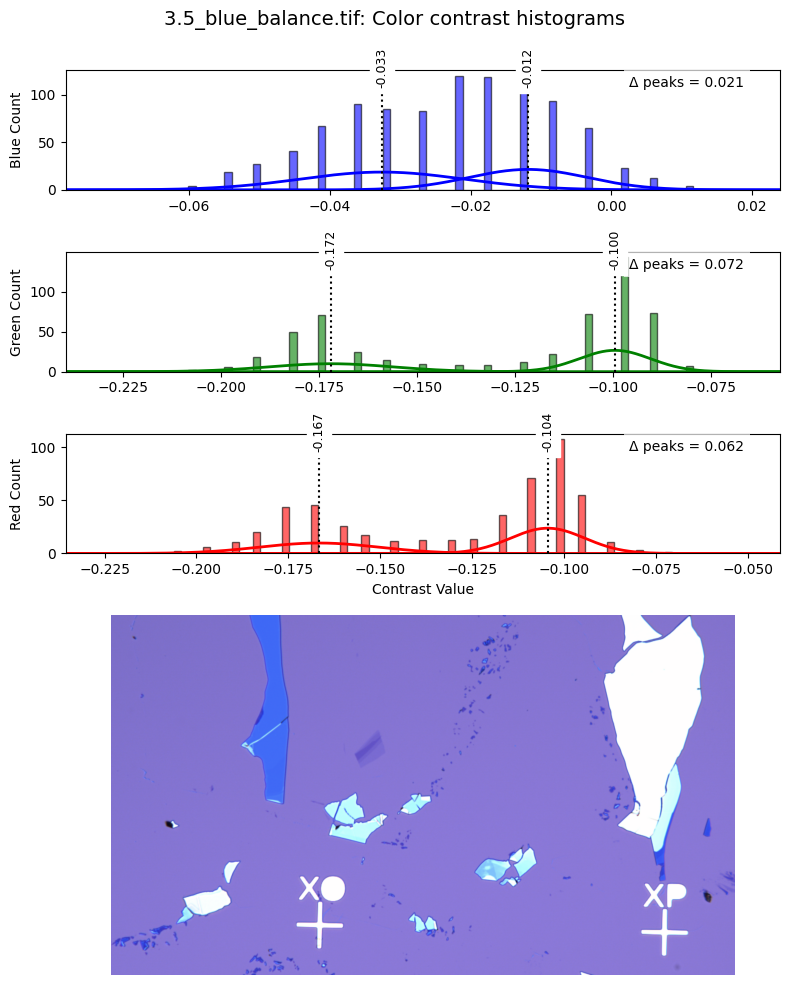

Saved histogram plot to ../Datasets/GMMDetectorDatasets/contrast_tests/blue_balance/results


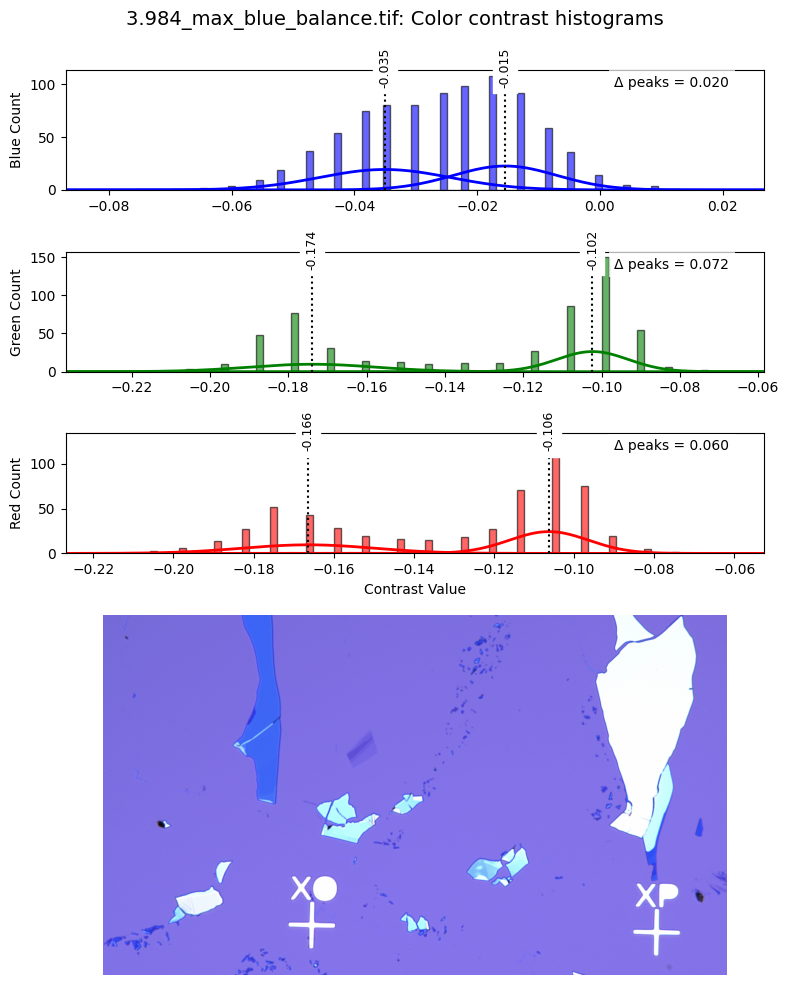

Saved histogram plot to ../Datasets/GMMDetectorDatasets/contrast_tests/blue_balance/results


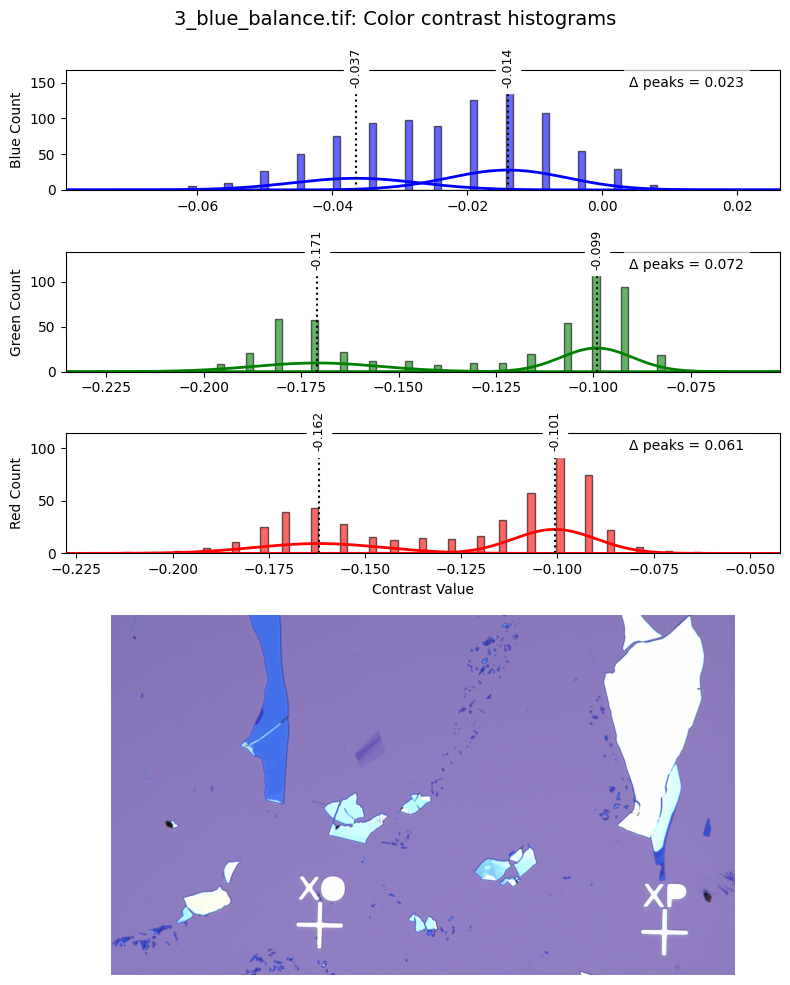

Saved histogram plot to ../Datasets/GMMDetectorDatasets/contrast_tests/blue_balance/results


In [5]:
USE_ONE_MASK = True

# Gets the mask files from the directory
mask_files = os.listdir(MASK_SAVE_DIRECTORY)
if not mask_files:
    print("No mask files found in the specified directory.")
    sys.exit(1)

# Gets the image files from the directory
image_files = os.listdir(IMAGE_DIRECTORY)
if not image_files:
    print("No image files found in the specified directory.")
    sys.exit(1)

# This will be the dict where each image path is saved with its datapoints contrast data
contrast_dict = {}

# If you want to use the same mask for all images, then the first mask in the dir is used
if USE_ONE_MASK:
    mask_name = mask_files[0]
    mask_path = os.path.join(MASK_SAVE_DIRECTORY, mask_name)
    print(f"Using mask: {mask_name}")

    for img in image_files:
        img_path = os.path.join(IMAGE_DIRECTORY, img)
        datapoints_contrast = get_contrasts_from_img(
            image_path=img_path,
            mask_path=mask_path,
            use_flatfield=USE_FLATFIELD,
            flatfield_path=FLATFIELD_PATH,
        )
        contrast_dict[img_path] = datapoints_contrast

else:
    for mask_name in mask_files:
        # Find the corresponding image
        image_path = os.path.join(IMAGE_DIRECTORY, mask_name)
        if not os.path.exists(image_path):
            image_path = os.path.join(
                IMAGE_DIRECTORY, mask_name.replace(".png", ".jpg", ".tif")
            )
        if not os.path.exists(image_path):
            print(f"Could not find image corresponding to mask '{mask_name}', skipping")
            continue

        mask_path = os.path.join(MASK_SAVE_DIRECTORY, mask_name)

        datapoints_contrast = get_contrasts_from_img(
            image_path=image_path,
            mask_path=mask_path,
            use_flatfield=USE_FLATFIELD,
            flatfield_path=FLATFIELD_PATH,
        )
        contrast_dict[image_path] = datapoints_contrast

# Show plots
create_histogram_plots(contrast_dict, save_results=SAVE_RESULTS, results_dir=RESULTS_DIRECTORY)
# It is highly likely some channels will not have distinct gaussians. This will produce this a convergence warning. Just ignore it, the code will still work as expected :)

